In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
sns.set_style("darkgrid")

In [3]:
# Get current folder of this notebook
notebook_dir = os.getcwd()  # Works in Jupyter or VSCode

# CSV is in the data/ subfolder
csv_file = os.path.join(notebook_dir, '..', 'data', 'LifeExpectancyData.csv')

In [9]:
if os.path.exists('data/LifeExpectancyData.csv'):
    df = pd.read_csv('data/LifeExpectancyData.csv')
    print(f"✅ Dataset loaded successfully: {df.shape}")
else:
    raise FileNotFoundError(f"❌ CSV file not found at {csv_file}")

✅ Dataset loaded successfully: (1649, 22)


In [10]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
df.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65,1154,...,6,8.16,65,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62,492,...,58,8.18,62,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64,430,...,62,8.13,64,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67,2787,...,67,8.52,67,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68,3013,...,68,7.87,68,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [11]:
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1649 entries, 0 to 1648
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          1649 non-null   object 
 1   year                             1649 non-null   int64  
 2   status                           1649 non-null   object 
 3   life_expectancy                  1649 non-null   float64
 4   adult_mortality                  1649 non-null   int64  
 5   infant_deaths                    1649 non-null   int64  
 6   alcohol                          1649 non-null   float64
 7   percentage_expenditure           1649 non-null   float64
 8   hepatitis_b                      1649 non-null   int64  
 9   measles                          1649 non-null   int64  
 10  bmi                              1649 non-null   float64
 11  under_five_deaths                1649 non-null   int64  
 12  polio               

In [12]:
#Drop rows with missing life expectancy
# -----------------------------
df = df.dropna(subset=['life_expectancy'])
print(f"New dataset shape after dropping missing life expectancy: {df.shape}")

New dataset shape after dropping missing life expectancy: (1649, 22)


In [13]:
print(df.describe())


              year  life_expectancy  adult_mortality  infant_deaths  \
count  1649.000000      1649.000000      1649.000000    1649.000000   
mean   2007.840509        69.302304       168.215282      32.553062   
std       4.087711         8.796834       125.310417     120.847190   
min    2000.000000        44.000000         1.000000       0.000000   
25%    2005.000000        64.400000        77.000000       1.000000   
50%    2008.000000        71.700000       148.000000       3.000000   
75%    2011.000000        75.000000       227.000000      22.000000   
max    2015.000000        89.000000       723.000000    1600.000000   

           alcohol  percentage_expenditure  hepatitis_b        measles  \
count  1649.000000             1649.000000  1649.000000    1649.000000   
mean      4.533196              698.973558    79.217708    2224.494239   
std       4.029189             1759.229336    25.604664   10085.802019   
min       0.010000                0.000000     2.000000       0.

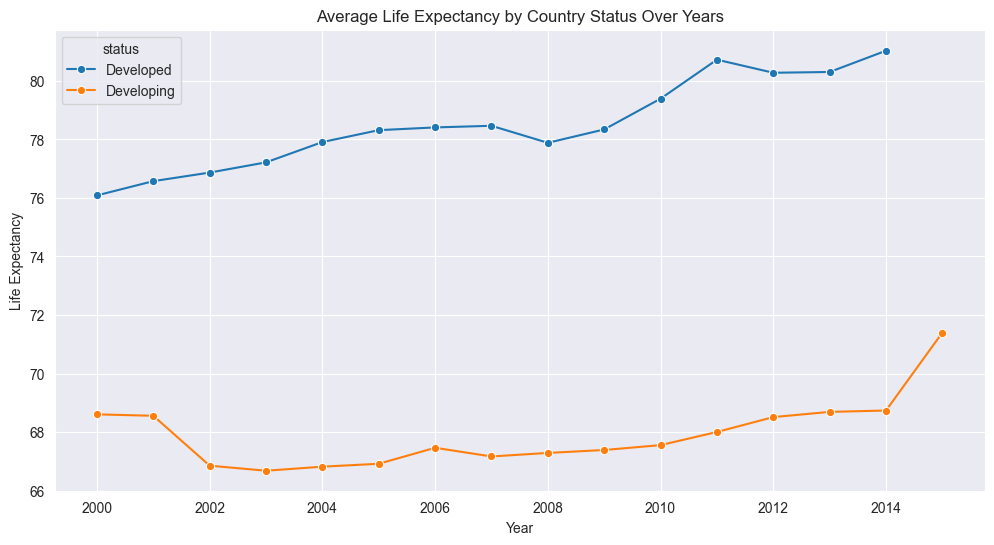

In [14]:
#1: Life Expectancy Trends per Continent
# -----------------------------
# We can create a different chart from the original: average life expectancy per continent per year
# First, check if 'continent' column exists; otherwise use grouping by 'status'
if 'continent' in df.columns:
    df_grouped = df.groupby(['year','continent'])['life_expectancy'].mean().reset_index()
    plt.figure(figsize=(12,6))
    sns.lineplot(data=df_grouped, x='year', y='life_expectancy', hue='continent', marker='o')
    plt.title("Average Life Expectancy by Continent Over Years")
else:
    df_grouped = df.groupby(['year','status'])['life_expectancy'].mean().reset_index()
    plt.figure(figsize=(12,6))
    sns.lineplot(data=df_grouped, x='year', y='life_expectancy', hue='status', marker='o')
    plt.title("Average Life Expectancy by Country Status Over Years")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.show()

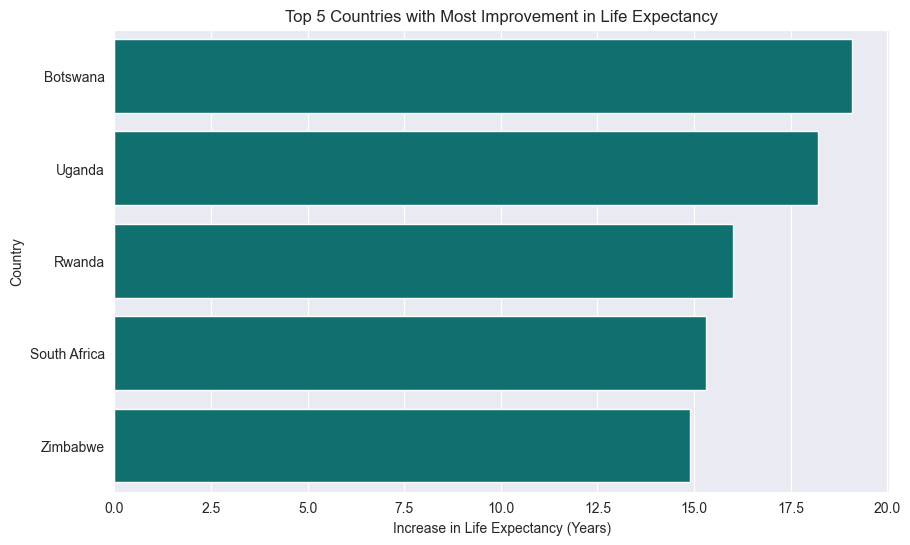

In [22]:
#2: Top 5 countries improving life expectancy the most (difference between first & last year)
# -----------------------------
life_change = df.groupby('country')['life_expectancy'].agg(['min','max'])
life_change['increase'] = life_change['max'] - life_change['min']
top5_improved = life_change.sort_values('increase', ascending=False).head(5).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='increase', y='country', data=top5_improved, color='teal')  # use color instead of palette
plt.title("Top 5 Countries with Most Improvement in Life Expectancy")
plt.xlabel("Increase in Life Expectancy (Years)")
plt.ylabel("Country")
plt.show()

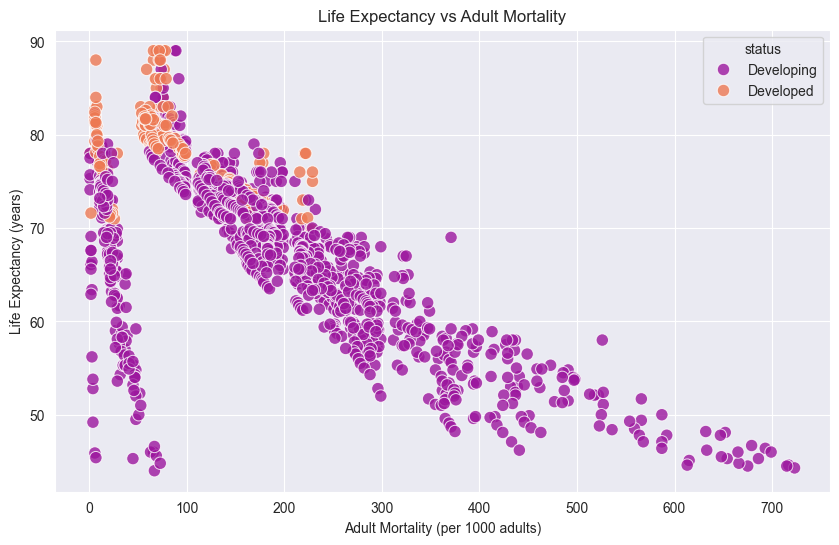

In [17]:
 #3: Scatter Plot - Life Expectancy vs Adult Mortality
# -----------------------------
scatter_data = df.dropna(subset=['adult_mortality', 'life_expectancy'])
plt.figure(figsize=(10,6))
sns.scatterplot(data=scatter_data, x='adult_mortality', y='life_expectancy',
                hue='status', palette='plasma', alpha=0.8, s=80)
plt.title("Life Expectancy vs Adult Mortality")
plt.xlabel("Adult Mortality (per 1000 adults)")
plt.ylabel("Life Expectancy (years)")
plt.show()


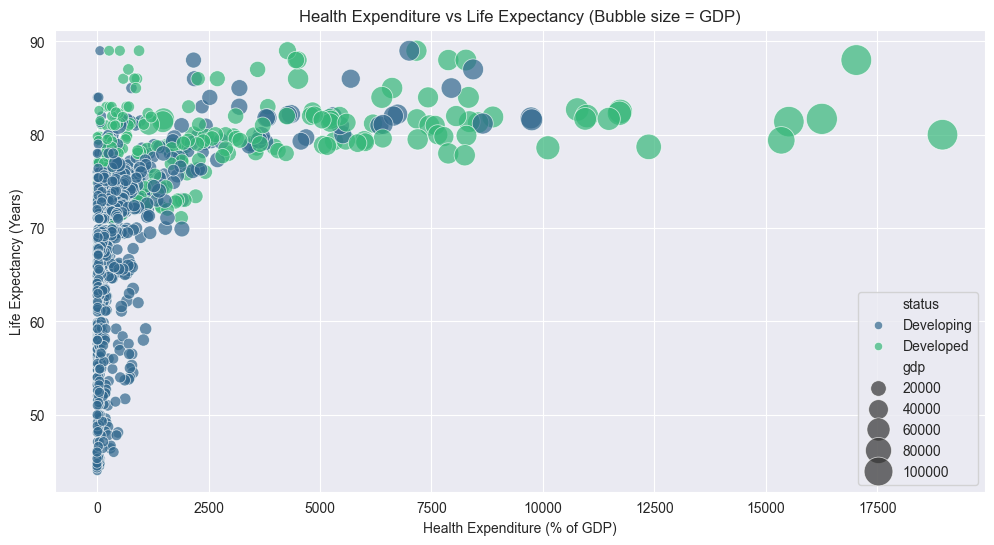

In [18]:
#4: Health Expenditure vs Life Expectancy (Bubble Plot)
# -----------------------------
df_bubble = df.dropna(subset=['percentage_expenditure', 'life_expectancy'])
plt.figure(figsize=(12,6))
sns.scatterplot(data=df_bubble,
                x='percentage_expenditure',
                y='life_expectancy',
                size='gdp',   # Bubble size based on GDP
                hue='status',
                palette='viridis',
                alpha=0.7,
                sizes=(50,500))
plt.title("Health Expenditure vs Life Expectancy (Bubble size = GDP)")
plt.xlabel("Health Expenditure (% of GDP)")
plt.ylabel("Life Expectancy (Years)")
plt.show()

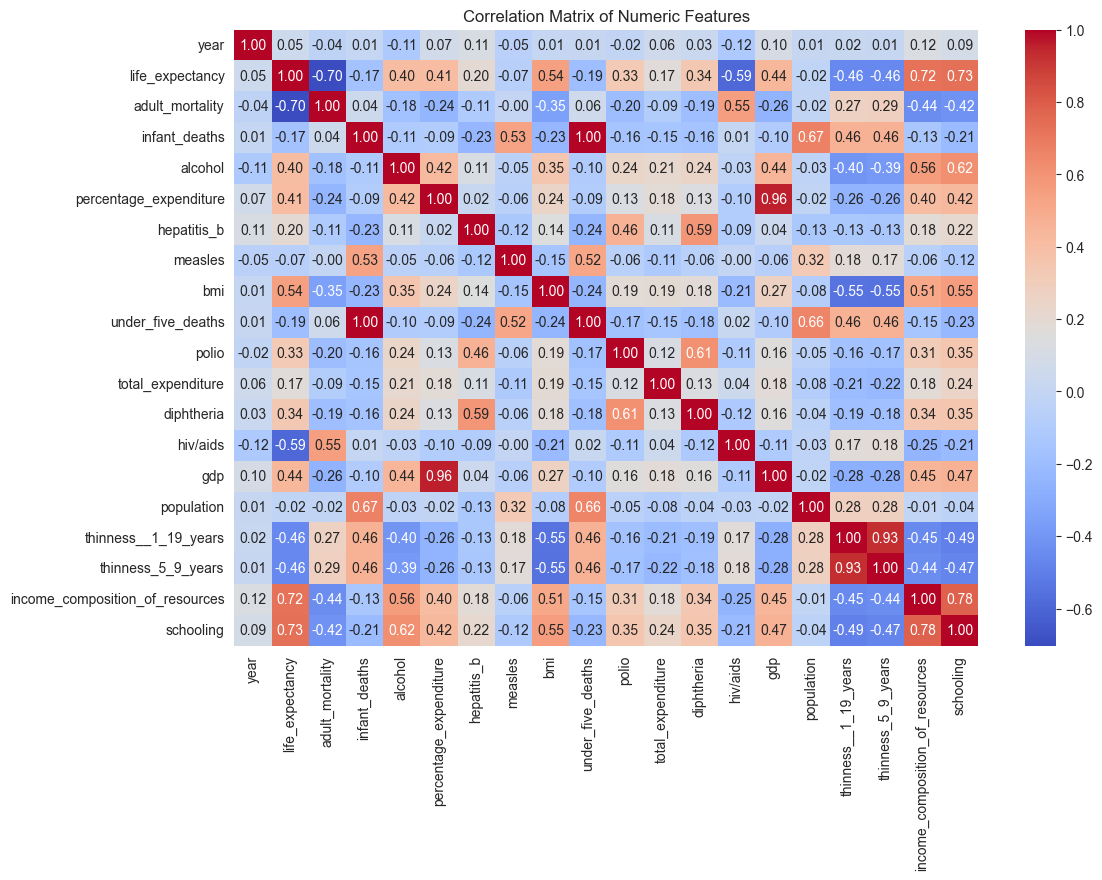

In [19]:
 #5: Correlation Heatmap
# -----------------------------
# Select numeric columns
numeric_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

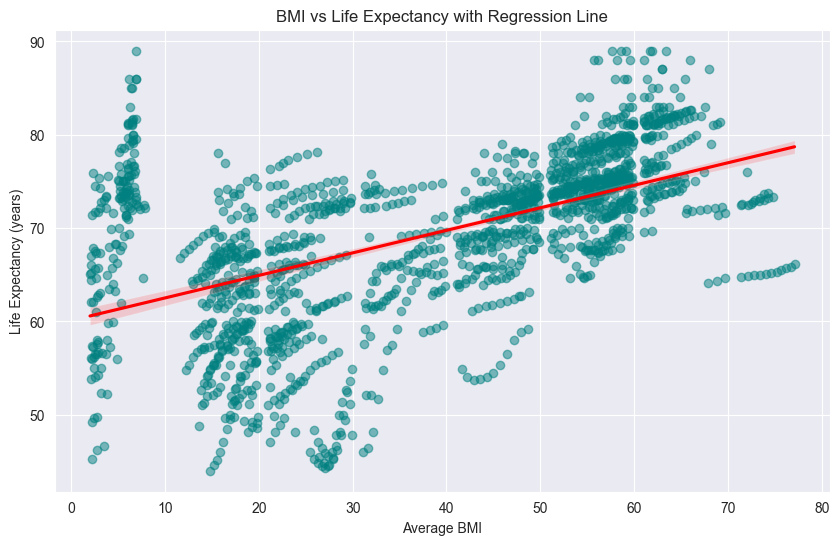

In [20]:
#6: BMI vs Life Expectancy with regression
# -----------------------------
plt.figure(figsize=(10,6))
sns.regplot(data=df, x='bmi', y='life_expectancy', scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red'})
plt.title("BMI vs Life Expectancy with Regression Line")
plt.xlabel("Average BMI")
plt.ylabel("Life Expectancy (years)")
plt.show()

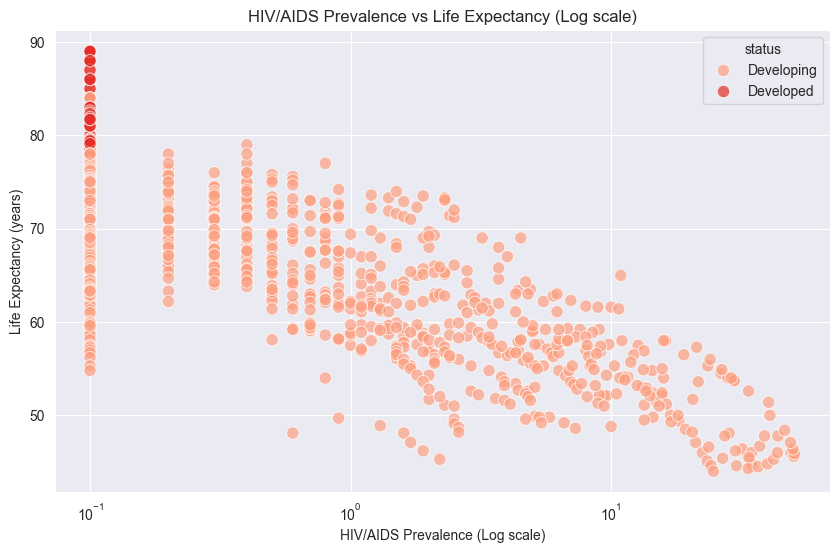

In [21]:
#7: HIV/AIDS Prevalence vs Life Expectancy (Log scale)
# -----------------------------
df_hiv = df.dropna(subset=['hiv/aids', 'life_expectancy'])
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_hiv, x='hiv/aids', y='life_expectancy', hue='status',
                palette='Reds', s=80, alpha=0.7)
plt.xscale('log')
plt.title("HIV/AIDS Prevalence vs Life Expectancy (Log scale)")
plt.xlabel("HIV/AIDS Prevalence (Log scale)")
plt.ylabel("Life Expectancy (years)")
plt.show()

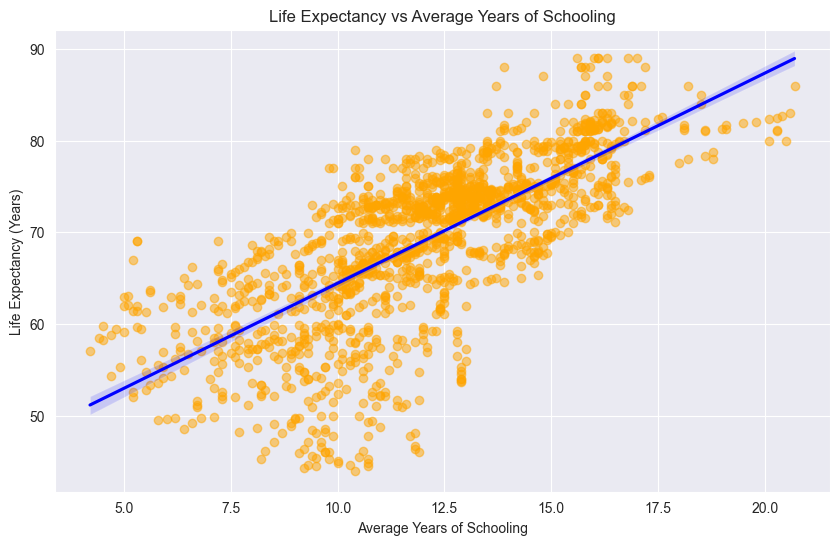

In [24]:
#8: Life Expectancy vs Schooling with Regression Line
plt.figure(figsize=(10,6))
df_school = df.dropna(subset=['schooling','life_expectancy'])
sns.regplot(data=df_school, x='schooling', y='life_expectancy', 
            scatter_kws={'alpha':0.5, 'color':'orange'}, 
            line_kws={'color':'blue'})
plt.title("Life Expectancy vs Average Years of Schooling")
plt.xlabel("Average Years of Schooling")
plt.ylabel("Life Expectancy (Years)")
plt.show()


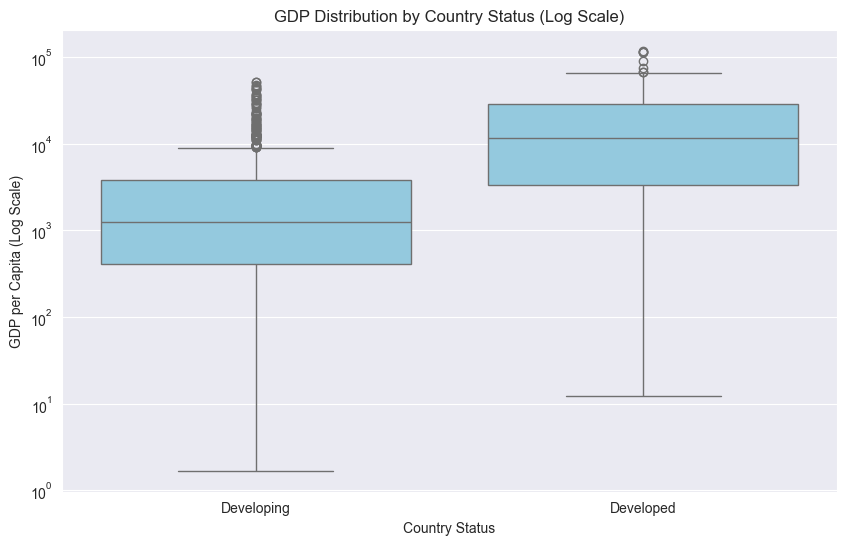

In [27]:
plt.figure(figsize=(10,6))
df_gdp = df.dropna(subset=['gdp'])
sns.boxplot(data=df_gdp, x='status', y='gdp', color='skyblue')  # Use color instead of palette
plt.yscale('log')  # log scale to handle large GDP differences
plt.title("GDP Distribution by Country Status (Log Scale)")
plt.xlabel("Country Status")
plt.ylabel("GDP per Capita (Log Scale)")
plt.show()


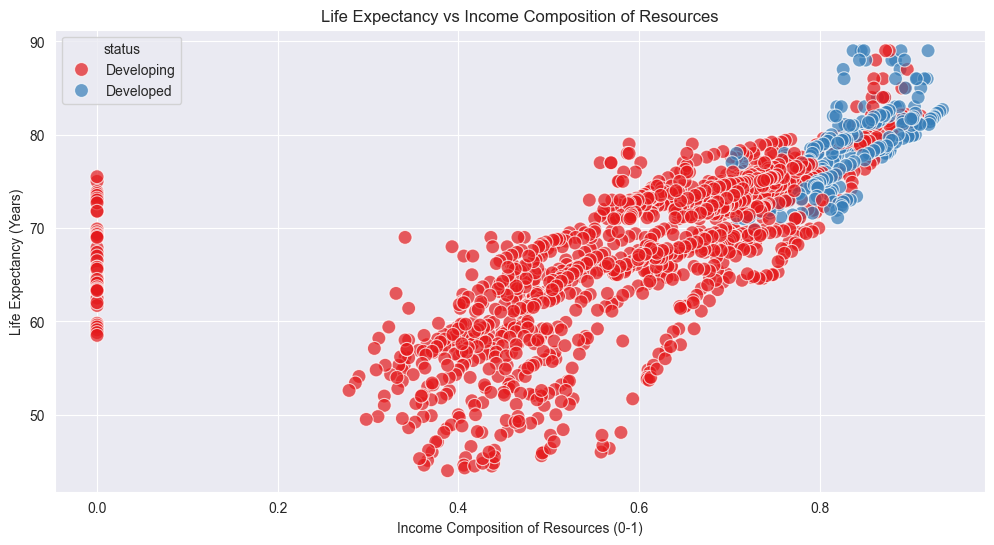

In [26]:
#10: Life Expectancy vs Income Composition with Color by Continent/Status
plt.figure(figsize=(12,6))
df_income = df.dropna(subset=['income_composition_of_resources','life_expectancy'])
if 'continent' in df.columns:
    hue_col = 'continent'
else:
    hue_col = 'status'
sns.scatterplot(data=df_income, x='income_composition_of_resources', y='life_expectancy',
                hue=hue_col, palette='Set1', s=100, alpha=0.7)
plt.title("Life Expectancy vs Income Composition of Resources")
plt.xlabel("Income Composition of Resources (0-1)")
plt.ylabel("Life Expectancy (Years)")
plt.show()




### **Observations from the Analyses**

1. **Life Expectancy Trends per Continent/Status**

   * Global life expectancy has generally increased over time.
   * Developed countries consistently have higher life expectancy than developing countries.
   * Some continents show faster improvement trends than others.

2. **Top 5 Countries with Most Improvement**

   * Certain countries have made remarkable progress in life expectancy over the years.
   * These improvements may be due to better healthcare, education, and economic growth.

3. **Life Expectancy vs Adult Mortality**

   * Strong negative correlation: higher adult mortality is associated with lower life expectancy.
   * The pattern is more pronounced in developing countries.

4. **Health Expenditure vs Life Expectancy (Bubble Plot)**

   * Positive correlation: countries spending more on healthcare generally have higher life expectancy.
   * Bubble size (GDP) shows that richer countries can invest more in health, further boosting life expectancy.

5. **Correlation Heatmap of Numeric Features**

   * Life expectancy positively correlates with schooling, income composition, and health expenditure.
   * Adult mortality, HIV/AIDS prevalence, and high BMI negatively correlate with life expectancy.

6. **BMI vs Life Expectancy with Regression**

   * Moderate correlation: very low or very high average BMI tends to reduce life expectancy.
   * Healthy BMI ranges are associated with higher life expectancy.

7. **HIV/AIDS Prevalence vs Life Expectancy (Log Scale)**

   * Countries with higher HIV/AIDS prevalence tend to have lower life expectancy.
   * Log scale highlights extreme cases without skewing the chart.

8. **Life Expectancy vs Schooling (Regression)**

   * Positive correlation: more years of schooling are associated with higher life expectancy.
   * Education likely improves health awareness and access to healthcare.

9. **GDP Distribution by Country Status (Boxplot, Log Scale)**

   * Developed countries have higher GDP per capita compared to developing countries.
   * GDP distribution in developing countries is more skewed, with few high-income outliers.

10. **Life Expectancy vs Income Composition**

    * Positive correlation: countries with better income distribution and resource allocation tend to have higher life expectancy.
    * Status/continent differences are visible, showing the impact of economic and social policies.


💡 **Key Takeaways**

* Life expectancy is influenced by multiple factors: **economic (GDP, income composition), health (adult mortality, health expenditure, HIV/AIDS), and social (schooling, BMI)**.
* Developed countries show consistent advantages, but some developing countries are rapidly improving.
* These analyses highlight the **interconnected nature of health, economy, and education**.
